In [9]:
import os
import shutil
import hashlib
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


# =========================
# CONFIG
# =========================
RAW_DATASET_DIR   = Path("wikiart") # initial dataset path
CLEAN_DATASET_DIR = Path("wikiart_clean") # new clean dataset path
SPLIT_DATASET_DIR = Path("wikiart_split") # dataset path to train/validation/test folder

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"} # allowed image extensions


TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.20 # for robust validation set / reliable tuning
TEST_SIZE    = 0.10
RANDOM_STATE = 42

assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-6


## 1. Preparation

### 1.1 Data Cleaning and Organisation

This script automates the preprocessing of raw images to ensure data quality and consistency:

- **Validation:** Filters out non-image files and identifies corrupted images using `img.verify()`.
- **Standardization:** Converts all images to RGB mode and saves them uniformly in JPEG format.
- **Tracking & Logging:** Returns detailed DataFrames (`kept_df` and `removed_df`) to audit the cleaning process.

In [2]:
def is_valid_image_file(file_path):
    """
    Checks if file suffixes in the directory correspond to any of the allowed image suffixes (specified as"
    global variable "IMG_EXTENSIONS").
    """
    return file_path.suffix.lower() in IMG_EXTENSIONS


def clean_dataset(raw_dir, clean_dir):

    """
    This function cleans and standardizes an image dataset organized by class folders.
    It scans a directory of images grouped into class subfolders and detects invalid or corrupted files.
    The clean dataset is saved in a new directory.
    """


    clean_dir.mkdir(parents=True, exist_ok=True) # creates the clean folder
    removed_files, kept_files = [], [] # lists to track removed/kept files

    class_dirs = [d for d in raw_dir.iterdir() if d.is_dir()] # list of all the class folder name

    for class_dir in class_dirs: # for each class

        target_class_dir = clean_dir / class_dir.name # a folder with the same namee is created inside the clean folder
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for file_path in class_dir.iterdir(): # for every file in each class folder

            if not file_path.is_file(): # skips non-files
                continue

            if not is_valid_image_file(file_path): # checks if image has a valid extension
                removed_files.append((str(file_path), "invalid")) # if not, the file is added to removed list
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify() # detects corrupted images

                with Image.open(file_path) as img: # reopen image after .verify()
                    img = img.convert("RGB") # convert to RGB format
                    output_filename = file_path.stem + ".jpg" # add correct extension
                    output_path = target_class_dir / output_filename 
                    img.save(output_path, format="JPEG", quality=95) # save in the correct path
                    kept_files.append((str(output_path), class_dir.name, img.width, img.height)) # add to kept files list

            except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as e:
                # raises error if file is not an image, corrupted or too large 
                removed_files.append((str(file_path), f"error opening/processing: {e}")) # file is added to removed list

    kept_df    = pd.DataFrame(kept_files,    columns=["filepath", "label", "width", "height"]) # kept list into df w/ filepath, label, width, height
    removed_df = pd.DataFrame(removed_files, columns=["filepath", "reason"]) # removed list into df
    return kept_df, removed_df


kept_df, removed_df = clean_dataset(
    raw_dir=RAW_DATASET_DIR,
    clean_dir=CLEAN_DATASET_DIR
)

print("Valid:",   len(kept_df))
print("Removed:", len(removed_df))

class_counts = kept_df["label"].value_counts().sort_values(ascending=False)
print("\nNumber of images per author:")
print(class_counts)


Valid: 13340
Removed: 0

Number of images per author:
label
Vincent_van_Gogh         1322
Nicholas_Roerich         1274
Pierre_Auguste_Renoir     975
Claude_Monet              934
Pyotr_Konchalovsky        644
Camille_Pissarro          621
Albrecht_Durer            580
John_Singer_Sargent       549
Rembrandt                 544
Marc_Chagall              536
Pablo_Picasso             534
Gustave_Dore              528
Boris_Kustodiev           444
Edgar_Degas               428
Paul_Cezanne              406
Ivan_Aivazovsky           404
Martiros_Saryan           403
Eugene_Boudin             389
Childe_Hassam             385
Ilya_Repin                378
Ivan_Shishkin             364
Raphael_Kirchner          362
Salvador_Dali             336
Name: count, dtype: int64


No invalid files were detected, therefore all images are kept in this preprocessing step and saved in a dataframe containing their respective filepath, label, width and height.

### 1.2 Outlier Detection
Before splitting, we detect and remove three types of problematic images:
1. **Exact duplicates** (MD5 hash) - prevents data leakage across splits
2. **Extreme aspect ratios** (>5:1 or <1:5) - heavily distorted when resized to 224x224
3. **Near-black or near-white images** - little to no visual information


In [3]:
# 1. Exact duplicates by MD5
def compute_md5(filepath):
    """Computes the MD5 hash of a file and returns it as a hexadecimal string."""
    with open(filepath, "rb") as f: # opens file in binary mode
        return hashlib.md5(f.read()).hexdigest() # produces 128-bit hash for the images and converts it to hexadecimal string

kept_df["md5"] = kept_df["filepath"].apply(compute_md5) # computes md5 hashes of all kept images and stores them in "md5" columns 
duplicates_mask = kept_df.duplicated(subset="md5", keep="first") # checks for duplicates and keeps only the first occurrence
print(f"Duplicates found: {duplicates_mask.sum()}")
kept_df = kept_df[~duplicates_mask].reset_index(drop=True)


# 2. Extreme aspect ratio (> 5:1 or < 1:5)
kept_df["aspect_ratio"] = kept_df["width"] / kept_df["height"] # computes image aspect ratio (width/height)
extreme_ratio_mask = (kept_df["aspect_ratio"] > 5) | (kept_df["aspect_ratio"] < 0.2)
print(f"Extreme aspect ratios: {extreme_ratio_mask.sum()}")
kept_df = kept_df[~extreme_ratio_mask].reset_index(drop=True) # keeps only images without extreme aspect ratios


# 3. Near-black or near-white images
def is_low_information(filepath, black_thresh=15, white_thresh=240, ratio_thresh=0.95):
    """
    Computes the fraction of pixels that are either very dark (all RGB channels below 'black_thresh') or very bright (all RGB channels
    above 'white_thresh'). Returns True if either fraction exceeds the specifiedd ratio 'ratio_thresh'."""

    with Image.open(filepath) as img:
        arr = np.array(img.convert("RGB"))
    n_total  = arr.shape[0] * arr.shape[1] # computes no. of pixels
    n_dark   = np.sum(np.all(arr < black_thresh,  axis=2)) # computes no. of px where all RGB channels are below the black threshold
    n_bright = np.sum(np.all(arr > white_thresh,  axis=2)) # computes no. of px where all RGB channels are above the white threshold
    return (n_dark / n_total > ratio_thresh) or (n_bright / n_total > ratio_thresh) # True if the ratio of black/white px is 
                                                                                    # above the specified ratio

low_info_mask = kept_df["filepath"].apply(is_low_information)
print(f"Low information images: {low_info_mask.sum()}")
kept_df = kept_df[~low_info_mask].reset_index(drop=True)


print(f"\nTotal after outlier detection: {len(kept_df)}")
print(kept_df["label"].value_counts())


Duplicates found: 2
Extreme aspect ratios: 0
Low information images: 0

Total after outlier detection: 13338
label
Vincent_van_Gogh         1322
Nicholas_Roerich         1274
Pierre_Auguste_Renoir     975
Claude_Monet              934
Pyotr_Konchalovsky        644
Camille_Pissarro          621
Albrecht_Durer            580
John_Singer_Sargent       549
Rembrandt                 544
Marc_Chagall              536
Pablo_Picasso             534
Gustave_Dore              528
Boris_Kustodiev           444
Edgar_Degas               428
Paul_Cezanne              406
Ivan_Aivazovsky           404
Martiros_Saryan           403
Eugene_Boudin             389
Childe_Hassam             383
Ilya_Repin                378
Ivan_Shishkin             364
Raphael_Kirchner          362
Salvador_Dali             336
Name: count, dtype: int64


Only two duplicates were found using the MD5 hashing method and thus removed from the dataframe.

### 1.3 Train/Val/Test

The following cell outlines the steps to split the dataset into training, validation, and test subsets. 70% of the images are assigned to the training set, while 20% and 10% are allocated to the validation and test sets, respectively. This ratio ensures a balanced proportion between the training and validation sets, reinforcing the reliability and robustness of the validation set during the tuning process.

In [4]:
def create_splits(df, train_size=0.70, val_size=0.15, test_size=0.15, random_state=42):
    train_df, temp_df = train_test_split(
        df, test_size=(1 - train_size),
        stratify=df["label"], random_state=random_state
    )
    val_relative = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_df, test_size=(1 - val_relative),
        stratify=temp_df["label"], random_state=random_state
    )
    return train_df, val_df, test_df


train_df, val_df, test_df = create_splits(
    kept_df, TRAIN_SIZE, VAL_SIZE, TEST_SIZE, RANDOM_STATE
)

print("Train:",      len(train_df))
print("Validation:", len(val_df))
print("Test:",       len(test_df))


def copy_files(df, split_name, base_dir):
    for _, row in df.iterrows():
        dst_dir = os.path.join(base_dir, split_name, row["label"])
        os.makedirs(dst_dir, exist_ok=True)
        dst = os.path.join(dst_dir, os.path.basename(row["filepath"]))
        if not os.path.exists(dst):
            shutil.copy(row["filepath"], dst)

copy_files(train_df, "train", SPLIT_DATASET_DIR)
copy_files(val_df,   "val",   SPLIT_DATASET_DIR)
copy_files(test_df,  "test",  SPLIT_DATASET_DIR)


Train: 9336
Validation: 2667
Test: 1335


Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


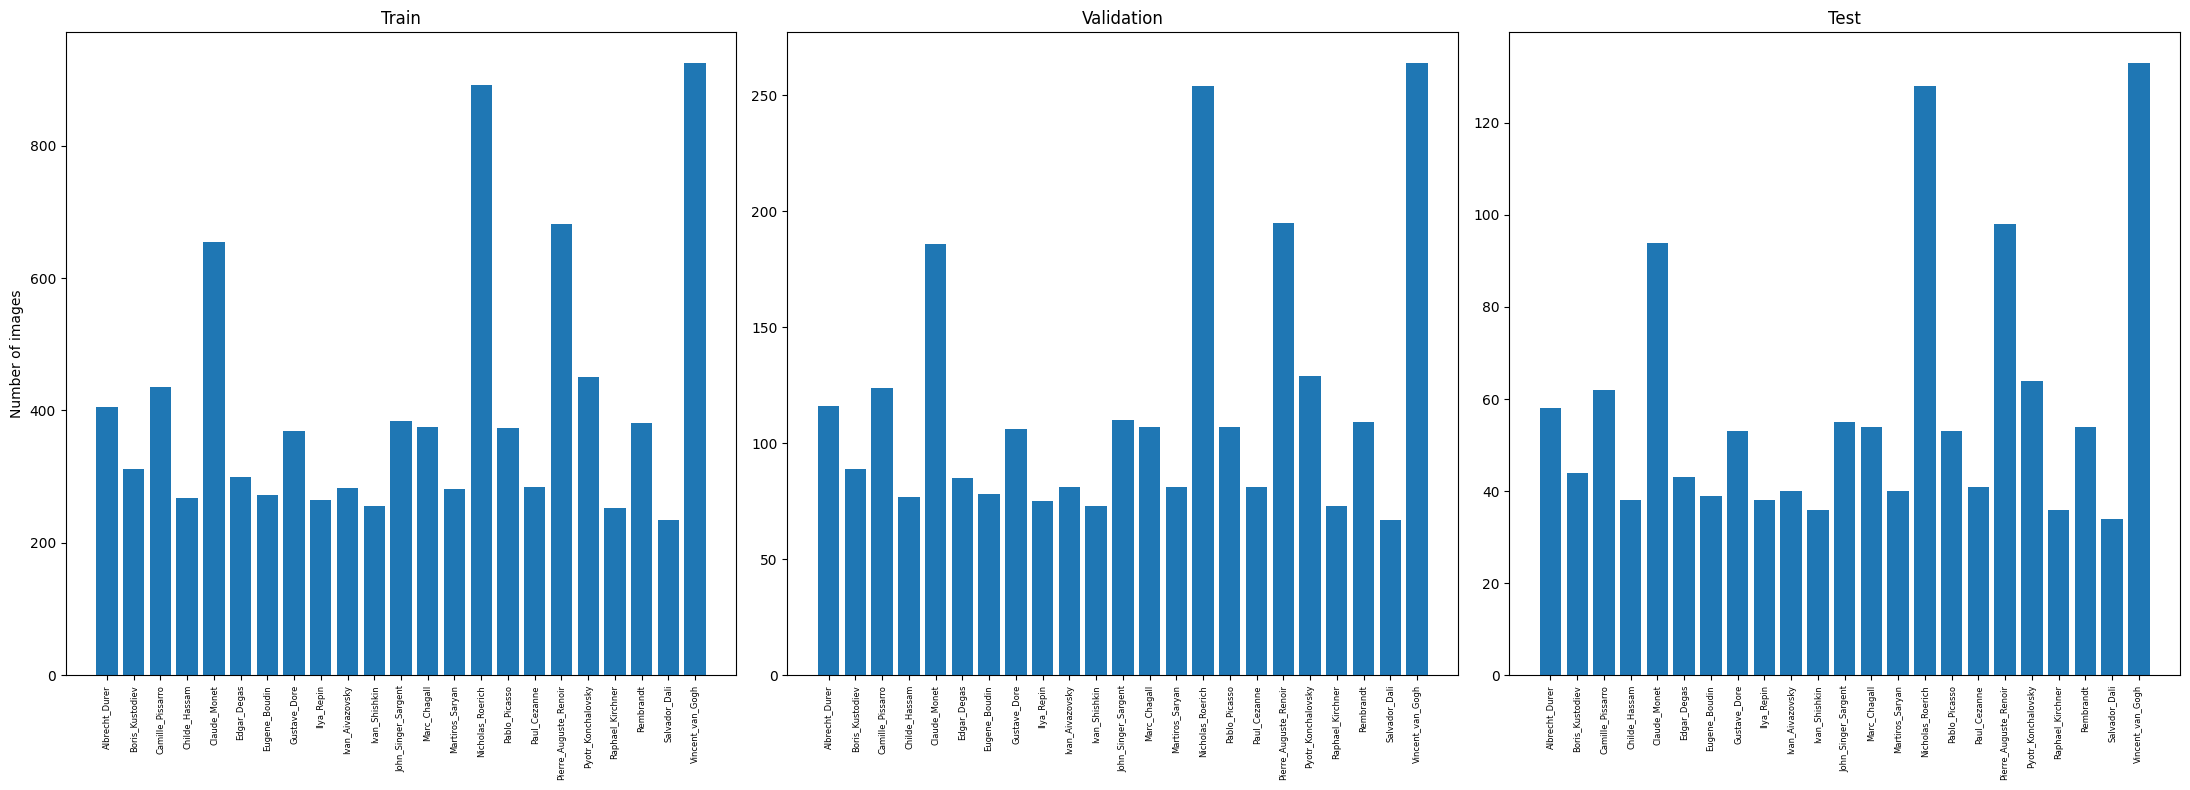

In [ ]:
current_directory = os.getcwd()

train_directory = os.path.join(current_directory, 'wikiart_split', 'train')
val_directory   = os.path.join(current_directory, 'wikiart_split', 'val')
test_directory  = os.path.join(current_directory, 'wikiart_split', 'test')

class_names = sorted([
    f for f in os.listdir(train_directory)
    if os.path.isdir(os.path.join(train_directory, f))
])
num_classes = len(class_names)
print(f'Classes ({num_classes}):', class_names)

def count_images(directory):
    counts = {}
    for folder in os.listdir(directory):
        path = os.path.join(directory, folder)
        if os.path.isdir(path):
            counts[folder] = len(os.listdir(path))
    return counts


train_counts = count_images(train_directory)
val_counts   = count_images(val_directory)
test_counts  = count_images(test_directory)

train_vals = [train_counts.get(c, 0) for c in class_names]
val_vals   = [val_counts.get(c, 0) for c in class_names]
test_vals  = [test_counts.get(c, 0) for c in class_names]

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Train plot
axes[0].bar(class_names, train_vals)
axes[0].set_title('Train')
axes[0].set_ylabel('Number of images')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)

# Val plot
axes[1].bar(class_names, val_vals)
axes[1].set_title('Validation')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)

# Test plot
axes[2].bar(class_names, test_vals)
axes[2].set_title('Test')
axes[2].tick_params(axis='x', rotation=90, labelsize=6)

plt.tight_layout()
plt.show()


As observed in the plots above, the datasets are highly imbalanced, which will require the use of appropriate classification metrics such as the F1 score and the area under the ROC curve in the future steps.